# 22DM015 Final Project — Financial PhraseBank
**Part 3 — Full-dataset SOA comparison**

## Preparations

In [1]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- Reproducibility seed (required by the assignment) ---
import os, random, sys
import numpy as np
import pandas as pd

import logging, warnings
# Tell transformers to skip its TensorFlow/Flax/Keras probe (we use PyTorch only).
os.environ.setdefault('USE_TF', '0')
os.environ.setdefault('USE_FLAX', '0')
os.environ.setdefault('TRANSFORMERS_NO_ADVISORY_WARNINGS', '1')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
# On Apple Silicon, let any op not yet implemented for the MPS backend fall back to CPU
# instead of erroring out. No-op on CUDA/CPU machines.
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('torch.distributed.elastic.multiprocessing.redirects').setLevel(logging.ERROR)
logging.getLogger('torchao').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message=r'.*Skipping import of cpp extensions.*')

import torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed, EarlyStoppingCallback)
import transformers
transformers.logging.set_verbosity_error()       # hide the per-load model LOAD REPORTs
transformers.logging.disable_progress_bar()
import datasets.utils.logging as _ds_logging
_ds_logging.disable_progress_bar()


# Make the shared helpers importable (they live in the repo root, one level up).
sys.path.append(os.path.abspath('..'))
import data_utils as du
import eval_utils as eu

SEED = du.SEED
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

splits = du.load_splits()            # identical train/val/test for everyone
train, val, test = splits['train'], splits['val'], splits['test']
# Part 3 keeps val HELD OUT (not folded into train): every Part 3 training early-stops on
# val and keeps the best-on-val checkpoint, so val must stay separate. The full-data curve
# point is therefore 1584, and the headline numbers are still measured on test only.
for k, v in splits.items():
    print(f'{k:11s} {len(v):5d}', dict(v['label_name'].value_counts()))

train        1584 {'neutral': np.int64(973), 'positive': np.int64(399), 'negative': np.int64(212)}
val           227 {'neutral': np.int64(140), 'positive': np.int64(57), 'negative': np.int64(30)}
test          453 {'neutral': np.int64(278), 'positive': np.int64(114), 'negative': np.int64(61)}
Last run: 2026-06-17 02:22:09


In [2]:
# watermark: AGLLM (AI-assisted content disclosure)
# Shared training helpers (mirrors bert_part2.ipynb so Part 3 stays runnable on its own).


# Pick the best available accelerator: CUDA (NVIDIA) > MPS (Apple Silicon) > CPU.
# The HF Trainer moves the model/batches onto this device automatically; we only use DEVICE
# to toggle the CPU-thread / pin-memory settings in TrainingArguments below.
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'torch {torch.__version__} | device: {DEVICE}')

if DEVICE == 'cpu':
    torch.set_num_threads(os.cpu_count() or 4)   # CPU training: use all cores
MODEL = 'bert-base-uncased'      # same as Part 2 for direct comparability
NUM_LABELS = 3
MAX_LEN = 128
EARLY_STOP_PATIENCE = 3

torch 2.12.0 | device: mps
Last run: 2026-06-17 02:22:09


In [3]:
# watermark: AGLLM (AI-assisted content disclosure)
tok = AutoTokenizer.from_pretrained(MODEL)


def encode(df, max_len=MAX_LEN):
    ds = Dataset.from_pandas(df[['text', 'label']], preserve_index=False)
    return ds.map(lambda b: tok(b['text'], truncation=True, padding='max_length', max_length=max_len),
                  batched=True)


def compute_metrics(eval_pred):
    # Same metric dict as Part 2 (eval_utils.evaluate), so 'f1_macro' (logged as
    # 'eval_f1_macro') drives best-checkpoint selection during early stopping.
    preds = eval_pred.predictions.argmax(-1)
    return eu.evaluate(eval_pred.label_ids, preds)


def train_bert(train_df, out_dir, *, val_df=None, epochs=20, batch=8, max_len=MAX_LEN,
               lr=2e-5, log_epochs=False, patience=EARLY_STOP_PATIENCE):
    """Full fine-tuning protocol, matching bert_part2.ipynb's full-FT setup (Part 3 uses
    full fine-tuning only — the stronger regime in Part 2's 2a — so there is no freeze
    switch here). EARLY STOPPING on the held-out val split: evaluate macro-F1 each epoch,
    keep the best-on-val checkpoint, and stop after `patience` epochs without improvement.
    Runs on whatever DEVICE the setup detected (CUDA / MPS / CPU).

    train_df -> the (possibly subsampled) TRAINING rows; the only thing that varies across
                the data-scaling curve. All ~110M params train.
    val_df   -> defaults to the shared held-out `val`; this is what early stopping watches.
                It is never subsampled, so every curve point is selected on the same fixed
                val and scored on the same fixed test.
    lr       -> 2e-5, the Part 2 full-fine-tuning rate (small, to nudge the pretrained
                backbone).
    log_epochs -> True logs train loss each epoch so the live notebook metrics TABLE shows
                a Training-Loss column too (as in Part 2); the eval rows show either way."""
    val_df = val if val_df is None else val_df
    set_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)

    args = TrainingArguments(
        output_dir=out_dir, seed=SEED,
        num_train_epochs=epochs, per_device_train_batch_size=batch,
        per_device_eval_batch_size=64, learning_rate=lr,
        eval_strategy='epoch', save_strategy='epoch', save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model='f1_macro', greater_is_better=True,
        logging_strategy='epoch' if log_epochs else 'no',
        report_to='none', disable_tqdm=False,          # keep the live notebook metrics TABLE (as Part 2)
        use_cpu=(DEVICE == 'cpu'),                     # otherwise let Trainer use CUDA/MPS
        dataloader_pin_memory=(DEVICE == 'cuda'),      # pin_memory only helps/works on CUDA
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=encode(train_df, max_len),
        eval_dataset=encode(val_df, max_len),          # early stopping watches val, never train
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)],
    )
    trainer.train()
    trainer.eval_max_len = max_len
    return trainer


def eval_split(trainer, df, max_len=None):
    max_len = max_len or getattr(trainer, 'eval_max_len', MAX_LEN)
    pred = trainer.predict(encode(df, max_len)).predictions.argmax(-1)
    return eu.evaluate(df['label'].values, pred)


def logged(method, full_row=False):
    """Latest TEST row for (MODEL, method) from the shared scoreboard. The eval module
    keys rows on (model, method, split, n_train_labeled) and no longer tracks person, so
    we match on MODEL + method here (each method has a single n in this notebook).
    Delete a row from results.csv to force that experiment to re-run."""
    if not eu.RESULTS_CSV.exists():
        return None
    r = pd.read_csv(eu.RESULTS_CSV)
    r = r[(r['model'] == MODEL) & (r['method'] == method) & (r['split'] == 'test')]
    if not len(r):
        return None
    row = r.iloc[-1]
    return row if full_row else {k: row[k] for k in eu.METRIC_KEYS}


def notes_kv(notes):
    """Parse the 'k=v; k=v' segments of a notes string into a dict."""
    out = {}
    for seg in str(notes).split(';'):
        if '=' in seg:
            k, v = seg.split('=', 1)
            out[k.strip()] = v.strip()
    return out


fmt = eu.fmt

Last run: 2026-06-17 02:22:10


## 3a.‍ Data-scaling curve (1 / 10 / 25 / 50 / 75 / 100 %)

For Part 3 we keep only the **best Part 2 configuration** — BERT with **full fine-tuning (no freezing)** — and apply the **exact same training protocol as Part 2**: up to 20 epochs with early stopping on the held-out validation macro-F1 (patience 3), learning rate `2e-5`, batch size 8, max length 128.‍ This is identical to `train_bert` in `bert_part2.ipynb`; the only thing we change is the amount of training data.‍

For 3a we build the data-scaling curve by training this same model on stratified subsets of the training set at **1%, 10%, 25%, 50%, 75%, and 100%** (`du.subset_by_fraction` preserves the class proportions at each fraction).‍ Validation and test are **never subsampled** — every point early-stops on the same fixed `val` and is scored on the same fixed `test` — so the curve isolates the effect of training-set size alone.‍ Each point is logged to `results.csv` and re-used on re-run unless the protocol changes.‍

In [ ]:
#47 minutes M4 Macbook Air
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3a — data-scaling curve. SAME protocol as Part 2's BEST model (full fine-tuning, NO
# freezing): up to 20 epochs with early stopping on the held-out val macro-F1 (patience 3),
# lr 2e-5, batch 8, max_len 128 -- i.e. train_bert's defaults, identical to bert_part2.ipynb.
# The ONLY thing that varies across the curve is the number of TRAINING rows.
CURVE = dict(epochs=20, batch=8, max_len=128, patience=3)    # == Part 2 full-FT protocol
FRACTIONS = [0.01, 0.10, 0.25, 0.50, 0.75, 1.00]             # increasing increments of train

curve_rows = []
for f in FRACTIONS:
    method = f'full-{int(f * 100)}%'
    sub = du.subset_by_fraction(train, f)                    # stratified subset; val/test untouched
    prev = logged(method, full_row=True)
    m = None
    if prev is not None:
        kv = notes_kv(prev['notes'])
        if (kv.get('epochs') == str(CURVE['epochs']) and kv.get('maxlen') == str(CURVE['max_len'])
                and kv.get('patience') == str(CURVE['patience'])):
            m = {k: prev[k] for k in eu.METRIC_KEYS}
            print(f"frac={f:>4}  n={len(sub):4d}  [cached]  macroF1={float(m['f1_macro']):.4f}")
        else:
            print(f"frac={f:>4}  [stale] logged row used a different protocol — retraining")
    if m is None:
        # full FT, early-stop on val; log_epochs=True keeps the live Part 2-style metrics table
        tr = train_bert(sub, '../.cache/bert_curve', lr=2e-5, log_epochs=True, **CURVE)
        m = eval_split(tr, test)
        eu.log_result(MODEL, method, len(sub), m,
                      notes=f"frac={f}; n={len(sub)}; full fine-tuning; lr=2e-5; "
                            f"epochs={CURVE['epochs']}; maxlen={CURVE['max_len']}; "
                            f"patience={CURVE['patience']}; early_stop=val_f1_macro")
        print(f"frac={f:>4}  n={len(sub):4d}  [trained] macroF1={float(m['f1_macro']):.4f}")
    curve_rows.append({'frac': f, 'n_train': len(sub), **m})

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,1.261942,1.118416,0.295154,0.237501,0.265559,0.062500,0.257310,0.392694
2,1.003448,1.017347,0.585903,0.396241,0.562185,0.000000,0.721190,0.467532
3,0.896538,0.926035,0.665198,0.406406,0.601384,0.000000,0.807453,0.411765
4,0.835574,0.870470,0.669604,0.401736,0.600060,0.000000,0.813456,0.391753
5,0.718292,0.828467,0.700441,0.449211,0.641548,0.000000,0.829114,0.518519
6,0.685552,0.805386,0.740088,0.497291,0.689775,0.000000,0.861953,0.629921
7,0.602633,0.801217,0.722467,0.489826,0.681277,0.000000,0.854093,0.615385
8,0.637266,0.800395,0.718062,0.490156,0.682256,0.000000,0.856089,0.614379
9,0.592929,0.790831,0.731278,0.502232,0.694857,0.000000,0.865672,0.641026
10,0.608393,0.769205,0.726872,0.496973,0.690089,0.000000,0.863469,0.627451


frac=0.01  n=  15  [trained] macroF1=0.4815


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.898927,0.678878,0.784141,0.528029,0.729279,0.000000,0.906667,0.677419
2,0.574685,0.513737,0.792952,0.535532,0.747093,0.000000,0.939929,0.666667
3,0.400991,0.444603,0.801762,0.538566,0.748957,0.000000,0.938776,0.676923
4,0.289634,0.415682,0.832599,0.644807,0.807256,0.235294,0.955882,0.743243
5,0.184029,0.349541,0.845815,0.714260,0.832017,0.450000,0.950355,0.742424
6,0.081437,0.289117,0.898678,0.848991,0.898777,0.760000,0.956204,0.830769
7,0.025988,0.270716,0.925110,0.907203,0.926387,0.896552,0.956204,0.868852
8,0.010420,0.316150,0.911894,0.875392,0.912261,0.814815,0.956522,0.854839
9,0.006477,0.313233,0.911894,0.879923,0.911972,0.836364,0.953405,0.850000
10,0.004950,0.326694,0.911894,0.880630,0.912382,0.836364,0.953069,0.852459


frac= 0.1  n= 158  [trained] macroF1=0.9005


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.764102,0.492869,0.797357,0.538364,0.750591,0.000000,0.943662,0.671429
2,0.376160,0.284064,0.920705,0.883173,0.919626,0.827586,0.964789,0.857143
3,0.140562,0.209523,0.925110,0.886197,0.924503,0.814815,0.967742,0.876033
4,0.045638,0.185817,0.947137,0.926729,0.947802,0.896552,0.974545,0.909091
5,0.021054,0.244199,0.951542,0.932194,0.952425,0.903226,0.978102,0.915254
6,0.002218,0.252953,0.947137,0.927918,0.947904,0.903226,0.974545,0.905983
7,0.003563,0.306916,0.942731,0.921072,0.943912,0.892857,0.974359,0.896000
8,0.004102,0.234717,0.951542,0.935944,0.952189,0.918033,0.974545,0.915254
9,0.000952,0.255931,0.955947,0.942701,0.956759,0.933333,0.978102,0.916667
10,0.000849,0.246496,0.955947,0.939790,0.956444,0.918033,0.978261,0.923077


...

frac= 0.5  n= 792  [trained] macroF1=0.9677


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.495035,0.219258,0.933921,0.890326,0.933280,0.800000,0.978417,0.892562
2,0.130834,0.165685,0.960352,0.944897,0.960622,0.915254,0.978261,0.941176
3,0.064994,0.105779,0.977974,0.961572,0.977944,0.931034,0.996416,0.957265
4,0.046950,0.226672,0.951542,0.938654,0.952616,0.931034,0.974359,0.910569
5,0.007666,0.344773,0.947137,0.929404,0.948257,0.909091,0.974359,0.904762
6,0.014040,0.181858,0.964758,0.952109,0.965205,0.933333,0.981818,0.941176


frac=0.75  n=1188  [trained] macroF1=0.9624


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.418629,0.154002,0.960352,0.931999,0.959306,0.857143,0.982332,0.956522
2,0.099992,0.134085,0.973568,0.950427,0.972807,0.892857,0.992908,0.965517
3,0.036473,0.087643,0.969163,0.945898,0.969445,0.903226,0.996416,0.938053
4,0.030518,0.134716,0.969163,0.947800,0.969558,0.903226,0.992806,0.947368
5,0.006400,0.184307,0.969163,0.953794,0.969435,0.931034,0.989170,0.941176
6,0.006957,0.114505,0.977974,0.962090,0.978061,0.933333,0.996416,0.956522
7,0.000200,0.184866,0.969163,0.949410,0.969340,0.915254,0.992806,0.940171
8,0.000154,0.200917,0.969163,0.949410,0.969340,0.915254,0.992806,0.940171
9,0.000130,0.208948,0.969163,0.949410,0.969340,0.915254,0.992806,0.940171


frac= 1.0  n=1584  [trained] macroF1=0.9792
Last run: 2026-06-17 03:09:37


Note that for all training the patience was hit so we trained for a sufficient number of epochs.‍ 

## 3b Learning Curve

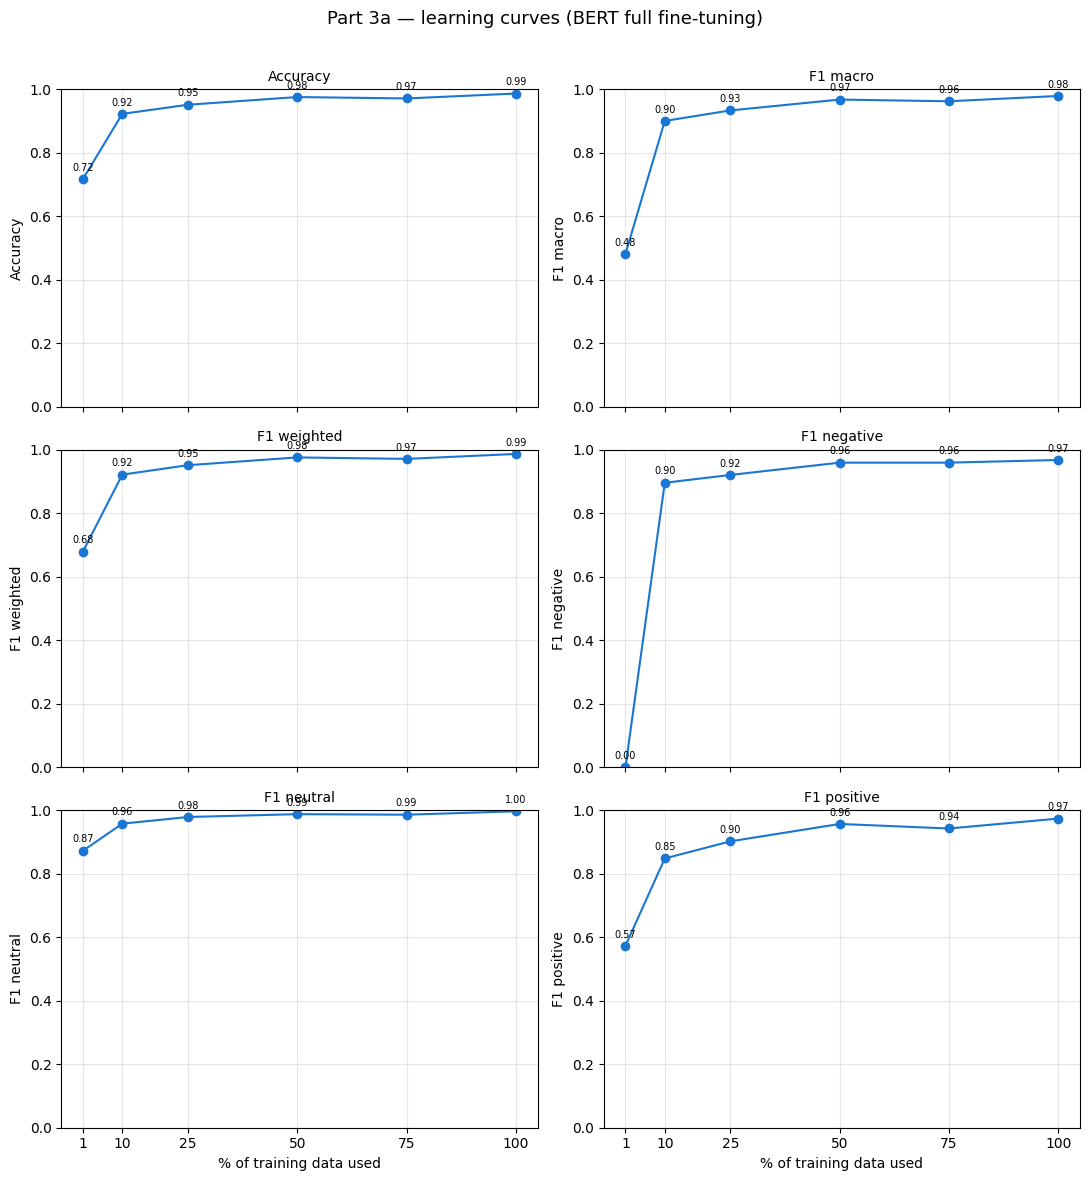

Last run: 2026-06-17 07:51:15


In [9]:
# watermark: AGLLM (AI-assisted content disclosure)
import matplotlib.pyplot as plt

# One panel per metric -> fills the 3x2 grid.
CURVE_METRICS = [('accuracy', 'Accuracy'), ('f1_macro', 'F1 macro'),
                 ('f1_weighted', 'F1 weighted'), ('f1_negative', 'F1 negative'),
                 ('f1_neutral', 'F1 neutral'), ('f1_positive', 'F1 positive')]


def plot_learning_curves(maxlen=None, title='Part 3a — learning curves (BERT full fine-tuning)'):
    """3x2 grid of learning curves, one panel per test metric, vs the % of training data used
    (linear x-axis). Reads the logged 'full-N%' rows from results.csv for the CURRENT curve
    protocol (matched on the maxlen recorded in notes), so it reflects whatever 3a has logged
    and ignores rows left from an older protocol."""
    maxlen = str(maxlen if maxlen is not None else CURVE['max_len'])
    res = pd.read_csv(eu.RESULTS_CSV)
    res = res[(res['model'] == MODEL) & (res['split'] == 'test')
              & res['method'].str.fullmatch(r'full-\d+%').fillna(False)]
    res = res[res['notes'].apply(lambda s: notes_kv(s).get('maxlen') == maxlen)]
    res = res.sort_values('n_train_labeled')
    if res.empty:
        print(f'[waiting] no logged full-N% rows for maxlen={maxlen} yet — run the 3a cell first')
        return res
    pct = res['method'].str.extract(r'full-(\d+)%')[0].astype(int).to_numpy()   # 1, 10, 25, 50, 75, 100

    fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharex=True)
    for ax, (key, label) in zip(axes.ravel(), CURVE_METRICS):
        y = res[key].astype(float).to_numpy()
        ax.plot(pct, y, marker='o', color='#1976d2')
        ax.set_title(label, fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_xticks(pct)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
        for x, yy in zip(pct, y):
            ax.annotate(f'{yy:.2f}', (x, yy), textcoords='offset points',
                        xytext=(0, 6), fontsize=7, ha='center')
    for ax in axes[-1]:
        ax.set_xlabel('% of training data used')
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    return res


_ = plot_learning_curves()

## 3c.‍ Technique comparison — LLM-generated augmentation across training percentages

_(Write your own rationale/analysis here — this is just a section marker.)_

we select the best technique from part 2 which is augmenting via LLM...‍  so we ahve generated 360 LLM sentences from the 32 and then we add these generated to each increament.‍ 

takes about 47 minutes


we then plot the same curve from 3b, overlayed with the new curve here so the curve here will contain for example, 1% + 360 LLM, 10% + 360 LLM

In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3c — incorporate the LLM data-generation technique (Part 2d) into the Part 3 training
# schema: rerun the SAME percentage schedule as 3a, but add the fixed LLM-generated set to
# each real subset before training. Same protocol as 3a (full FT, lr 2e-5, maxlen 128, batch 8,
# up to 20 epochs, early-stop on val). x stays the % of REAL data so this curve overlays 3a's.
# RESUME-AWARE: a row is reused only if its notes match the current protocol AND gen-set size.
gen_3c = pd.read_csv('../data/llm_generated.csv')[['text', 'label']]   # fixed LLM-generated pool

aug_curve_rows = []
for f in FRACTIONS:
    method = f'llmgen-{int(f * 100)}%'
    sub = du.subset_by_fraction(train, f)                          # f% of REAL train (stratified)
    combo = pd.concat([sub[['text', 'label']], gen_3c], ignore_index=True)
    prev = logged(method, full_row=True)
    m = None
    if prev is not None:
        kv = notes_kv(prev['notes'])
        if (kv.get('epochs') == str(CURVE['epochs']) and kv.get('maxlen') == str(CURVE['max_len'])
                and kv.get('patience') == str(CURVE['patience']) and kv.get('gen') == str(len(gen_3c))):
            m = {k: prev[k] for k in eu.METRIC_KEYS}
            print(f"frac={f:>4}  real={len(sub):4d} +gen={len(gen_3c)} -> n={len(combo):4d}  [cached]  macroF1={float(m['f1_macro']):.4f}")
        else:
            print(f"frac={f:>4}  [stale] logged row used a different protocol/gen-set — retraining")
    if m is None:
        tr = train_bert(combo, '../.cache/bert_3c_llmgen', lr=2e-5, log_epochs=True, **CURVE)
        m = eval_split(tr, test)
        eu.log_result(MODEL, method, len(sub), m,                 # n = REAL labels at this %, for x-axis alignment with 3a
                      notes=f"3c llm-gen aug; frac={f}; real={len(sub)}; gen={len(gen_3c)}; n={len(combo)}; "
                            f"full fine-tuning; lr=2e-5; epochs={CURVE['epochs']}; maxlen={CURVE['max_len']}; "
                            f"patience={CURVE['patience']}; early_stop=val_f1_macro")
        print(f"frac={f:>4}  real={len(sub):4d} +gen={len(gen_3c)} -> n={len(combo):4d}  [trained] macroF1={float(m['f1_macro']):.4f}")
    aug_curve_rows.append({'frac': f, 'n_real': len(sub), 'n_total': len(combo), **m})

pd.DataFrame(aug_curve_rows)

In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)
# 3c overlay: the real-only data-scaling curve (3a, 'full-N%') vs the LLM-generated augmented
# curve ('llmgen-N%'), one panel per metric, both vs the % of REAL training data. Reads the
# current-protocol rows from results.csv, so it fills in as the cells above finish.
def plot_curve_overlay(maxlen=None, title='Part 3c — real-only vs + LLM-generated (per metric)'):
    maxlen = str(maxlen if maxlen is not None else CURVE['max_len'])
    res = pd.read_csv(eu.RESULTS_CSV)
    res = res[(res['model'] == MODEL) & (res['split'] == 'test')]
    res = res[res['notes'].apply(lambda s: notes_kv(s).get('maxlen') == maxlen)]

    def series(prefix):
        d = res[res['method'].str.fullmatch(prefix + r'-\d+%').fillna(False)].copy()
        if d.empty:
            return None
        d['pct'] = d['method'].str.extract(r'-(\d+)%')[0].astype(int)
        return d.sort_values('pct')

    base, aug = series('full'), series('llmgen')
    if base is None and aug is None:
        print('[waiting] no logged curve rows yet for this protocol — run 3a and the 3c cell first')
        return
    ticks = (aug if aug is not None else base)['pct'].to_numpy()

    fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharex=True)
    for ax, (key, label) in zip(axes.ravel(), CURVE_METRICS):
        if base is not None:
            ax.plot(base['pct'], base[key].astype(float), marker='o', color='#9e9e9e', label='real only')
        if aug is not None:
            ax.plot(aug['pct'], aug[key].astype(float), marker='o', color='#1976d2', label='+ LLM-generated')
        ax.set_title(label, fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_xticks(ticks)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
    axes[0, 0].legend(fontsize=8, loc='lower right')
    for ax in axes[-1]:
        ax.set_xlabel('% of real training data')
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


plot_curve_overlay()

## 3e Methodology Analysis

Ask AI to update the code to include the models from part 3 here.‍ HOWEVER this will be too much so I suggest select only the models representatives.‍ Also make sure to do no or minimal duplicate with part2 narrative because we already compared the part 2 models in part 2 notebook.‍

In [ ]:
# watermark: AGLLM (AI-assisted content disclosure)
# Reusable Part-2 results chart. plot_metrics(keys) draws all six test metrics in a 3x2
# grid for the given variants, reading results.csv at call time so it always reflects the
# latest logged rows. Variants are sorted by macro-F1 and share that one order across every
# panel, so a given variant sits at the same row in all six -> easy cross-metric scan.
# Regime is shown by colour; the (full)/(probe) tag only disambiguates the BERT variants
# that appear in both regimes.
CHART_VARIANTS = {   # key -> (model, method, short label, regime)
    'random':    ('random-prior',      'baseline',             'Random',             'Baseline'),
    'rule':      ('rule-based',        'baseline',             'Rule-based',         'Baseline'),
    '2a-probe':  ('bert-base-uncased', '32-shot-frozen',       '2a 32-shot (probe)', 'Linear probe'),
    '2b-probe':  ('bert-base-uncased', 'augmented-frozen',     '2b aug (probe)',     'Linear probe'),
    '2d-probe':  ('bert-base-uncased', 'llm-generated-frozen', '2d LLM-gen (probe)', 'Linear probe'),
    '2a-full':   ('bert-base-uncased', '32-shot',              '2a 32-shot (full)',  'Full fine-tune'),
    '2b-full':   ('bert-base-uncased', 'augmented',            '2b aug (full)',      'Full fine-tune'),
    '2d-full':   ('bert-base-uncased', 'llm-generated',        '2d LLM-gen (full)',  'Full fine-tune'),
    '2e-full':   ('bert-base-uncased', 'llm-full',             '2e all-LLM (full)',  'Full fine-tune'),
    '2e-combo':  ('bert-base-uncased', 'llm-bt-combo',         '2e LLM+BT (full)',   'Full fine-tune'),
    'zero-shot': ('claude-opus-4-8',   'zero-shot',            'Zero-shot LLM',      'Zero-shot'),
}
CHART_COLORS = {'Baseline': '#9e9e9e', 'Linear probe': '#ff9800',
                'Full fine-tune': '#1976d2', 'Zero-shot': '#43a047'}
CHART_METRICS = [('accuracy', 'Accuracy'), ('f1_macro', 'F1 macro'),
                 ('f1_weighted', 'F1 weighted'), ('f1_negative', 'F1 negative'),
                 ('f1_neutral', 'F1 neutral'), ('f1_positive', 'F1 positive')]


def plot_metrics(keys, title='Part 2 — test metrics by variant (rows ordered by macro-F1)'):
    """Bar-chart grid of the six test metrics for the given CHART_VARIANTS keys.
    Reads results.csv at call time, so it always reflects the latest logged rows; a key
    with no logged TEST row yet is skipped with a [waiting] note instead of erroring."""
    res = pd.read_csv(eu.RESULTS_CSV)
    res = res[res['split'] == 'test']
    rows = []
    for k in keys:
        model, method, label, regime = CHART_VARIANTS[k]
        hit = res[(res['model'] == model) & (res['method'] == method)]
        if len(hit):
            r = hit.iloc[-1]
            rows.append({'label': label, 'regime': regime,
                         **{mk: float(r[mk]) for mk, _ in CHART_METRICS}})
        else:
            print(f'[waiting] no logged row yet for: {label}')
    if not rows:
        print('[waiting] nothing to plot yet')
        return
    rows.sort(key=lambda d: d['f1_macro'])            # one fixed order shared by every panel
    labels = [d['label'] for d in rows]
    bar_colors = [CHART_COLORS[d['regime']] for d in rows]

    fig, axes = plt.subplots(3, 2, figsize=(12, 11), sharey=True)
    for ax, (mk, mtitle) in zip(axes.ravel(), CHART_METRICS):
        vals = [d[mk] for d in rows]
        ax.barh(labels, vals, color=bar_colors)
        ax.set_xlim(0, 1)
        ax.set_title(mtitle, fontsize=10)
        for y, v in enumerate(vals):
            ax.text(v + 0.01, y, f'{v:.2f}', va='center', fontsize=7)
    present = [rg for rg in CHART_COLORS if any(d['regime'] == rg for d in rows)]
    handles = [plt.Rectangle((0, 0), 1, 1, color=CHART_COLORS[rg]) for rg in present]
    fig.legend(handles, present, loc='lower center', ncol=len(present), fontsize=9)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0.04, 1, 0.97])
    plt.show()